In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/request_level_data.csv")

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 29209 entries, 0 to 29208
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   request_id                  29209 non-null  int64  
 1   timestamp                   29209 non-null  str    
 2   scenario                    29209 non-null  str    
 3   endpoint_name               29209 non-null  str    
 4   endpoint_path               29209 non-null  str    
 5   payload_size                29209 non-null  int64  
 6   response_time_ms            29209 non-null  float64
 7   status_code                 29209 non-null  int64  
 8   active_requests             29209 non-null  int64  
 9   rps_10s                     29209 non-null  float64
 10  requests_last_60s           29209 non-null  int64  
 11  client_send_ts              29209 non-null  str    
 12  client_receive_ts           29209 non-null  str    
 13  client_observed_latency_ms  29209 non-null

,request_id,payload_size,response_time_ms,status_code,active_requests,rps_10s,requests_last_60s,client_observed_latency_ms
count,29209.000000,29209.000000,29209.000000,29209.000000,29209.000000,29209.000000,29209.000000,29209.000000
mean,7311.463761,427.280188,300.787335,206.811188,7.942312,7.673173,437.999452,311.123646
std,4231.085207,388.989734,216.971930,44.832791,6.702520,2.821160,149.030510,220.140980
min,1.000000,10.000000,20.000000,200.000000,1.000000,0.100000,1.000000,13.500000
25%,3652.000000,166.000000,154.290000,200.000000,3.000000,5.800000,351.000000,158.650000
50%,7303.000000,308.000000,232.590000,200.000000,6.000000,7.700000,451.000000,245.340000
75%,10954.000000,570.000000,378.540000,200.000000,11.000000,9.400000,527.000000,390.920000
max,15109.000000,2000.000000,3228.920000,503.000000,86.000000,16.300000,728.000000,3249.990000


In [3]:
df.isnull().sum()

request_id                    0
timestamp                     0
scenario                      0
endpoint_name                 0
endpoint_path                 0
payload_size                  0
response_time_ms              0
status_code                   0
active_requests               0
rps_10s                       0
requests_last_60s             0
client_send_ts                0
client_receive_ts             0
client_observed_latency_ms    0
dtype: int64

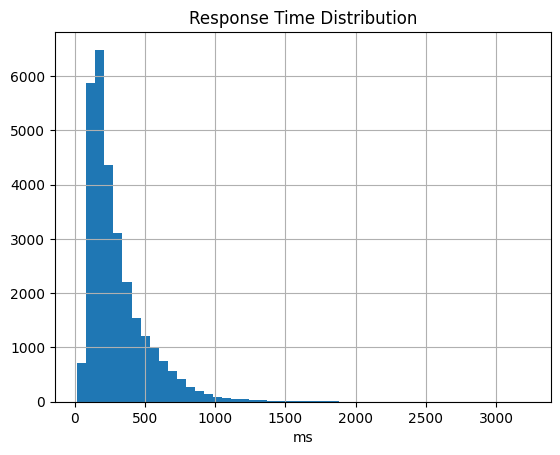

In [6]:
import matplotlib.pyplot as plt

df["response_time_ms"].hist(bins=50)
plt.title("Response Time Distribution")
plt.xlabel("ms")
plt.show()

### Gözlem

- Response time değerleri çoğunlukla 100–400 ms aralığında yoğunlaşmaktadır.  
- Dağılım sağa çarpık olup yüksek değerlerde uzun bir kuyruk bulunmaktadır . 

### Yorum

- Sistem çoğunlukla stabil çalışmakta, ancak nadir durumlarda yüksek gecikmeler üretmektedir.  
- Bu durum performans anomalilerine işaret etmektedir.  

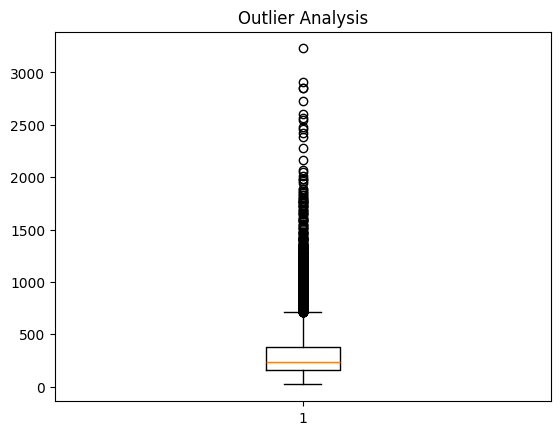

In [21]:
plt.boxplot(df["response_time_ms"])
plt.title("Outlier Analysis")
plt.show()

### Gözlem

- Veri setinde çok sayıda aykırı değer bulunmaktadır.  
- Maksimum değerler ortalamaya göre oldukça yüksektir.  

### Yorum

- Bu aykırı değerler sistemde ani yüklenmeler veya darboğazlar ile ilişkili olabilir. 
- Bu değerlerin analizde tutulması sistem davranışını anlamak açısından önemlidir.

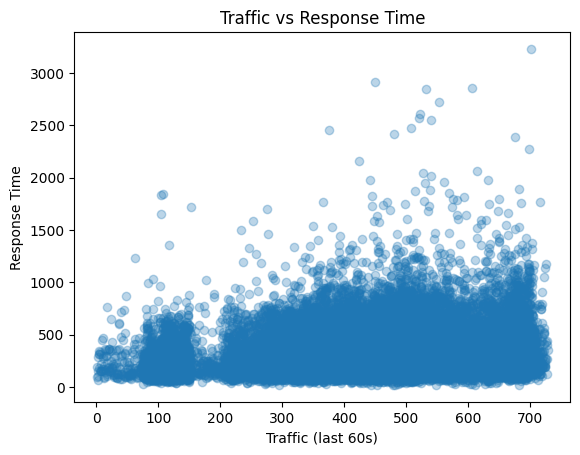

In [8]:
plt.scatter(df["requests_last_60s"], df["response_time_ms"], alpha=0.3)
plt.xlabel("Traffic (last 60s)")
plt.ylabel("Response Time")
plt.title("Traffic vs Response Time")
plt.show()

### Gözlem

- Trafik arttıkça response time değerlerinin dağılımı genişlemektedir. 

### Yorum

- Yüksek trafik altında sistem performansı düşmekte ve gecikmeler artmaktadır.  
- Bu durum sistemin ölçeklenebilirlik sınırlarını göstermektedir.

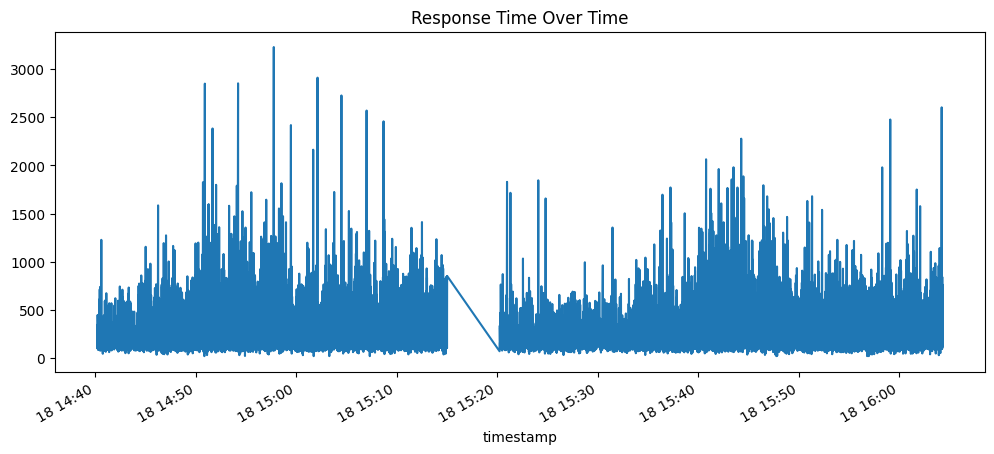

In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

df.set_index("timestamp", inplace=True)

df["response_time_ms"].plot(figsize=(12,5))
plt.title("Response Time Over Time")
plt.show()

### Gözlem

- Response time değerleri zaman içerisinde dalgalı bir yapı göstermektedir.  
- Belirli zamanlarda ani artışlar (spike) gözlemlenmektedir.  

### Yorum

- Sistem performansı dinamik olup yük değişimlerinden etkilenmektedir.  
- Ani spike’lar geçici performans problemlerine işaret etmektedir.  

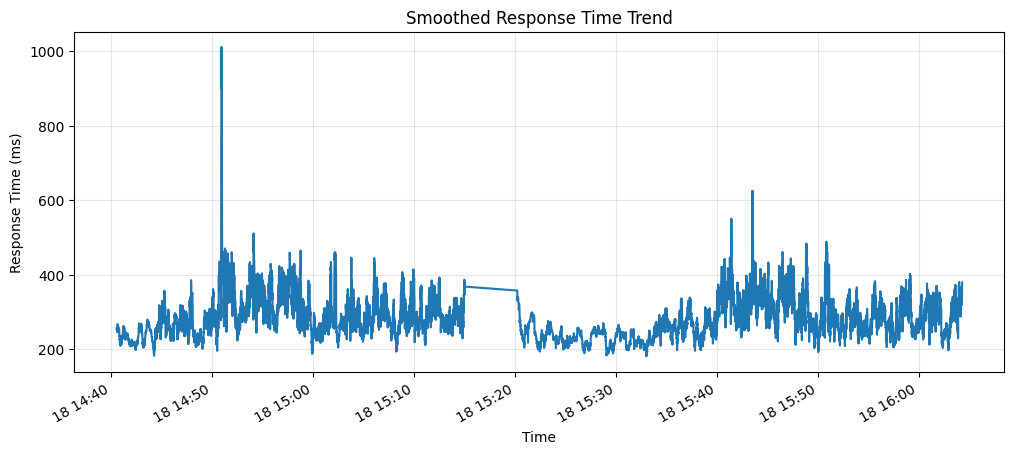

In [19]:
df["response_time_ms"].rolling(window=50).mean().plot(figsize=(12,5))

plt.title("Smoothed Response Time Trend")
plt.xlabel("Time")
plt.ylabel("Response Time (ms)")
plt.grid(alpha=0.3)   # daha soft grid

plt.show()

### Gözlem

- Gürültü azaltıldığında sistemin temel trendi daha net gözlemlenmektedir.  

### Yorum

- Sistem performansı zaman içerisinde dalgalı ancak belirli trendler içermektedir.  
- Rolling mean, gerçek sistem davranışını daha sağlıklı analiz etmeyi sağlamaktadır.  

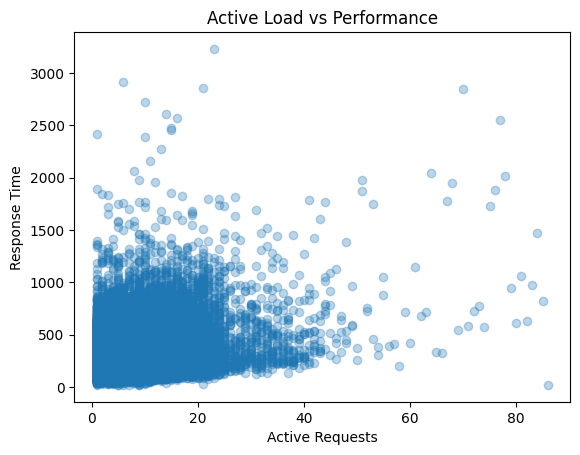

In [10]:
plt.scatter(df["active_requests"], df["response_time_ms"], alpha=0.3)
plt.xlabel("Active Requests")
plt.ylabel("Response Time")
plt.title("Active Load vs Performance")
plt.show()

### Gözlem

- Aktif istek sayısı arttıkça response time değerleri artmaktadır.  

### Yorum

- Sistem performansı anlık yük ile doğrudan ilişkilidir.  
- Bu değişken modelleme açısından önemli bir feature’dır.  

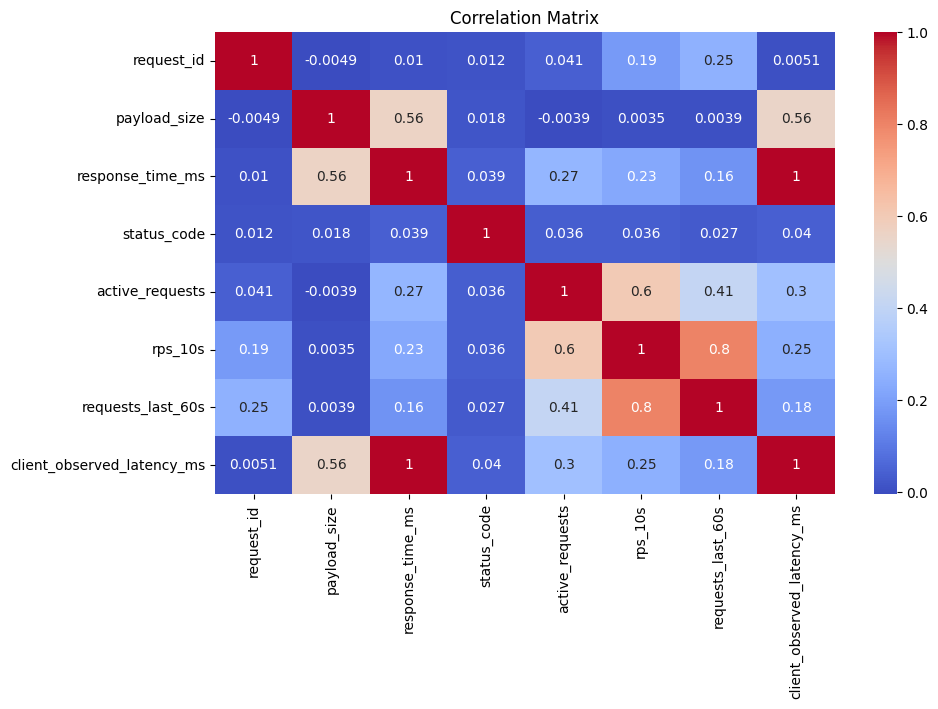

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Gözlem

- Response time ile payload size ve trafik metrikleri arasında pozitif ilişki bulunmaktadır.  

### Yorum

- Sistem performansı veri boyutu ve trafik ile doğrudan etkilenmektedir.  
- Bazı trafik metrikleri yüksek korelasyon göstermektedir.  

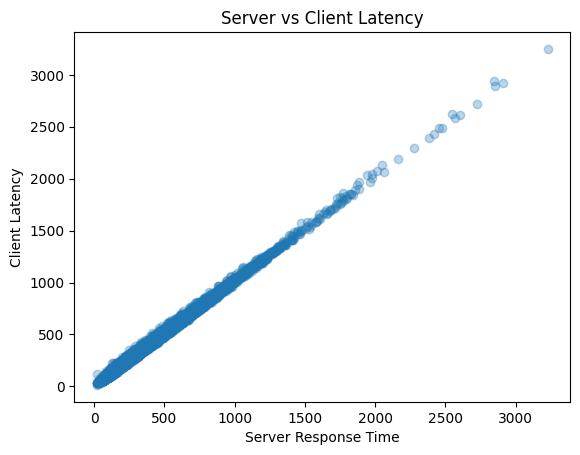

In [13]:
plt.scatter(df["response_time_ms"], df["client_observed_latency_ms"], alpha=0.3)
plt.xlabel("Server Response Time")
plt.ylabel("Client Latency")
plt.title("Server vs Client Latency")
plt.show()
df["response_time_ms"].rolling(window=50).mean().plot(figsize=(12,5))
plt.title("Smoothed Response Time Trend")
plt.xlabel("Time")
plt.ylabel("Response Time (ms)")
plt.grid()
plt.show()

### Gözlem

- Server response time ile client latency arasında doğrusal bir ilişki bulunmaktadır. 

### Yorum

- Sunucu performansı kullanıcı deneyimini doğrudan etkilemektedir.  
- Performans iyileştirmeleri kullanıcı memnuniyetine katkı sağlayacaktır. 